# Project 4: Image Classification using TensorFlow

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

# Set seeds for reproducibility
import random
random.seed(42)
tf.random.set_seed(42)

Mounted at /content/drive


In [2]:
# I saved the dataset in my Google Drive
save_dir = '/content/drive/MyDrive/beans_data'

def preprocess_500(image, label):
    # normalize to 0-1
    image = tf.cast(image, tf.float32) / 255.0
    # keep original 500x500 size
    return image, label

def preprocess_224(image, label):
    # normalize to 0-1
    image = tf.cast(image, tf.float32) / 255.0
    # resize to 224x224
    image = tf.image.resize(image, [224, 224])
    return image, label

# keeps images at the original 500 x 500 size
def to_tf_dataset(images, labels, batch_size=32, shuffle=False):
    # convert numpy arrays to TensorFlow dataset
    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    # apply normalization to each image
    ds = ds.map(preprocess_500, num_parallel_calls=tf.data.AUTOTUNE)
    # cache dataset in memory after first load
    ds = ds.cache()
    # shuffle 1000 samples at a time
    if shuffle:
        ds = ds.shuffle(1000)
    # group into batches and prefetch next batch during training
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# resizes the images to 224 x 224 to reduce training time
def to_tf_dataset_224(images, labels, batch_size=32, shuffle=False):
    # convert numpy arrays to TensorFlow dataset
    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    # apply normalization and resize each image
    ds = ds.map(preprocess_224, num_parallel_calls=tf.data.AUTOTUNE)
    # cache dataset in memory after first load
    ds = ds.cache()
    # shuffle 1000 samples at a time
    if shuffle:
        ds = ds.shuffle(1000)
    # group into batches and prefetch next batch during training
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [3]:
train_images = np.load(f'{save_dir}/train_images.npy')
train_labels = np.load(f'{save_dir}/train_labels.npy')
val_images   = np.load(f'{save_dir}/validation_images.npy')
val_labels   = np.load(f'{save_dir}/validation_labels.npy')
test_images  = np.load(f'{save_dir}/test_images.npy')
test_labels  = np.load(f'{save_dir}/test_labels.npy')

# Convert to tf datasets
train_ds = to_tf_dataset(train_images, train_labels, shuffle=True)
val_ds   = to_tf_dataset(val_images, val_labels)
test_ds  = to_tf_dataset(test_images, test_labels)

# Use the smaller resized images when I need to reduce training time
train_ds_224 = to_tf_dataset_224(train_images, train_labels, shuffle=True)
val_ds_224   = to_tf_dataset_224(val_images, val_labels)
test_ds_224  = to_tf_dataset_224(test_images, test_labels)
IMAGE_SHAPE_224 = (224, 224, 3)

print(f"Train batches        : {len(train_ds)}")
print(f"Validation batches   : {len(val_ds)}")
print(f"Test batches         : {len(test_ds)}")

# Take one batch from the training set to get image sizes
images, labels = next(iter(train_ds))

batch_size = images.shape[0]
image_height = images.shape[1]
image_width  = images.shape[2]
color_channels = images.shape[3]
IMAGE_SHAPE = (image_height, image_width, color_channels)

print(f"Batch size     : {batch_size}")
print(f"Image height   : {image_height}")
print(f"Image width    : {image_width}")
print(f"Color channels : {color_channels}")
print(f"Image shape    : {IMAGE_SHAPE}")


Train batches        : 33
Validation batches   : 5
Test batches         : 4
Batch size     : 32
Image height   : 500
Image width    : 500
Color channels : 3
Image shape    : (500, 500, 3)


# Build the CNN

In [4]:
model = keras.Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=IMAGE_SHAPE_224),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and classify
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')   # 3 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # labels are integers, not one-hot
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

## Training the models takes a long time, so save checkpoints

In [5]:
# Paths for both models
cp_path_original  = '/content/drive/MyDrive/beans_data/cnn_original/cp.weights.h5'
cp_path_augmented = '/content/drive/MyDrive/beans_data/cnn_augmented/cp.weights.h5'

# Create checkpoint callbacks
cp_callback_original = tf.keras.callbacks.ModelCheckpoint(
    filepath=cp_path_original,
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

cp_callback_augmented = tf.keras.callbacks.ModelCheckpoint(
    filepath=cp_path_augmented,
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

# Train the CNN

Use the 224x224 size images to speed up training

In [7]:
early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

history = model.fit(
        train_ds_224,
        epochs=50,
        validation_data=val_ds_224,
        callbacks=[early_stop, cp_callback_original]
    )

# Save history as CSV
orig_history_path = '/content/drive/MyDrive/beans_data/cnn_original_history.csv'
pd.DataFrame(history.history).to_csv(orig_history_path, index=False)
print("History saved to Drive!")

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4605 - loss: 1.3275
Epoch 1: val_loss improved from None to 0.79432, saving model to /content/drive/MyDrive/beans_data/cnn_original/cp.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/beans_data/cnn_original/cp.weights.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 130s 4s/step - accuracy: 0.5058 - loss: 1.0926 - val_accuracy: 0.6316 - val_loss: 0.7943
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6405 - loss: 0.7920
Epoch 2: val_loss improved from 0.79432 to 0.65987, saving model to /content/drive/MyDrive/beans_data/cnn_original/cp.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/beans_data/cnn_original/cp.weights.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 140s 4s/step - accuracy: 0.6576 - loss: 0.7603 - val_accuracy: 0.7143 - val_loss: 0.6599
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6855 - loss: 0.6917
Epoch 3: val_loss did not improve from 0.65987
33/33 ━━━━━━━━━━━━━━━━━━━

# Plot and Evaluate

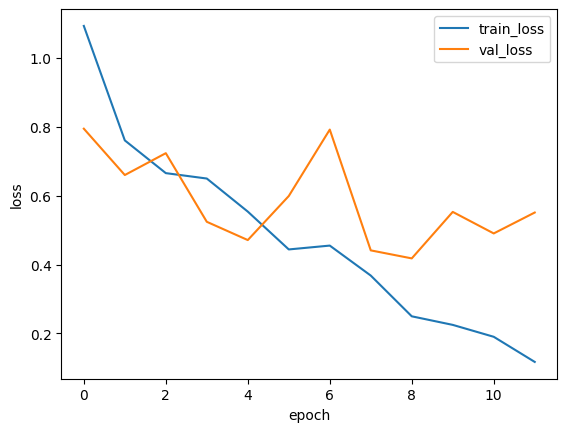

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 970ms/step - accuracy: 0.8047 - loss: 0.4819
Test accuracy : 80.47%


In [8]:
trainhist = pd.DataFrame(history.history)
trainhist['epoch'] = history.epoch

sns.lineplot(x='epoch', y='loss',     data=trainhist, label='train_loss')
sns.lineplot(x='epoch', y='val_loss', data=trainhist, label='val_loss')
plt.legend()
plt.show()

test_loss, test_accuracy = model.evaluate(test_ds_224)
print(f"Test accuracy : {test_accuracy:.2%}")

# The CNN model is Underfitting.  The validation loss has a positive slope and is getting larger.  It is moving away from the training loss and there is a large gap between the two lines.

# Augmented Learning

In [6]:
data_augmentation = tf.keras.Sequential(
  [
    tf.keras.layers.RandomFlip("horizontal_and_vertical",
                                input_shape=IMAGE_SHAPE_224),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomTranslation(height_factor=0.05,width_factor = 0.05 ),
    tf.keras.layers.RandomZoom(height_factor=(0.05, 0.05))
  ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
aug_model = keras.Sequential([

    # Data Augmentation
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and classify
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

aug_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
aug_history_path = '/content/drive/MyDrive/beans_data/cnn_augmented_history.csv'

if os.path.exists(cp_path_augmented):
    print("Found saved weights — loading from Drive...")
    aug_model.load_weights(cp_path_augmented)
    aug_history_data = pd.read_csv(aug_history_path)
    aug_hist = aug_history_data.copy()
    aug_hist['epoch'] = range(len(aug_hist))
    print("Weights and history loaded!")
else:
    print("No saved weights found — training from scratch...")
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True)
    print("Fitting augmented model...")
    aug_history = aug_model.fit(
        train_ds_224,
        epochs=50,
        validation_data=val_ds_224,
        callbacks=[early_stop, cp_callback_augmented])
    aug_hist = pd.DataFrame(aug_history.history)
    aug_hist['epoch'] = aug_history.epoch

    # Save history as CSV
    pd.DataFrame(aug_history.history).to_csv(aug_history_path, index=False)
    print("History saved to Drive!")

No saved weights found — training from scratch...
Fitting augmented model...
Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3876 - loss: 1.3625
Epoch 1: val_loss improved from None to 0.93195, saving model to /content/drive/MyDrive/beans_data/cnn_augmented/cp.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/beans_data/cnn_augmented/cp.weights.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 145s 4s/step - accuracy: 0.4362 - loss: 1.1713 - val_accuracy: 0.5263 - val_loss: 0.9320
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4933 - loss: 0.9594
Epoch 2: val_loss improved from 0.93195 to 0.70934, saving model to /content/drive/MyDrive/beans_data/cnn_augmented/cp.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/beans_data/cnn_augmented/cp.weights.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 138s 4s/step - accuracy: 0.5493 - loss: 0.9152 - val_accuracy: 0.6917 - val_loss: 0.7093
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6317 - loss

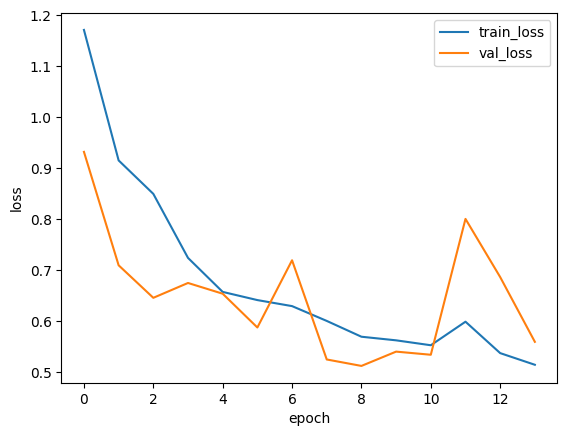

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 902ms/step - accuracy: 0.7812 - loss: 0.4927
Augmented CNN - Test accuracy : 78.12%


In [11]:
sns.lineplot(x='epoch', y='loss',     data=aug_hist, label='train_loss')
sns.lineplot(x='epoch', y='val_loss', data=aug_hist, label='val_loss')
plt.legend()
plt.show()

aug_loss, aug_accuracy = aug_model.evaluate(test_ds_224)
print(f"Augmented CNN - Test accuracy : {aug_accuracy:.2%}")

## The augmented model reduced overfitting but did not outperform the standard CNN in terms of accuracy.  It only scored a 78.12% compared to the standard's 80.47%.

## I suspect that with a dataset of only ~1000 images, data augmentation introduced too much noise.  Perhaps if I set the patience higher or increased the number of epochs it would eventually converge and outperform the standard model.

# Transfer Learning

I was running out of RAM in Google Colab.  Resize the images before using MobileNetV3Large to use less memory.

In [4]:
# Reload datasets at 224x224 for transfer learning
train_ds_224 = to_tf_dataset_224(train_images, train_labels, shuffle=True)
val_ds_224   = to_tf_dataset_224(val_images, val_labels)
test_ds_224  = to_tf_dataset_224(test_images, test_labels)

# Confirm new size
images, labels = next(iter(train_ds_224))
print(f"New image shape: {images.shape}")

IMAGE_SHAPE = (224, 224, 3)

New image shape: (32, 224, 224, 3)


In [5]:
base_model = tf.keras.applications.MobileNetV3Large(
    input_shape=IMAGE_SHAPE_224,
    include_top=False, # Remove the fully-connected layer
    weights='imagenet' # Pre-training on ImageNet
    )

# don't retrain the weights
base_model.trainable = False

preprocess_input = tf.keras.applications.mobilenet_v3.preprocess_input

# take a batch of data and check the size of the feature matrix
image_batch, label_batch = next(iter(train_ds_224))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

# convert it to a 2D matrix
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

global_average_layer = tf.keras.layers.Flatten()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

# add the classification layer
prediction_layer = tf.keras.layers.Dense(3)
prediction_batch = prediction_layer(feature_batch_average)
print(f'The size of the predicted value for a given batch = {prediction_batch.shape}')

# create the model using transfer learning
data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    tf.keras.layers.RandomZoom(height_factor=(0.1, 0.1))
])

inputs  = tf.keras.Input(shape=IMAGE_SHAPE_224)
x = data_aug(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model_transfer = tf.keras.Model(inputs, outputs)

LEARNING_RATE = 0.0001
model_transfer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

(32, 7, 7, 960)
(32, 960)
(32, 47040)
The size of the predicted value for a given batch = (32, 3)


In [6]:
model_transfer.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 47040)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 47040)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │       141,123 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137,475 (11.97 MB)

 Trainable params: 141,123 (551.26 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [8]:
%%time
callback = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3)
epochs = 20

transfer_history = model_transfer.fit(
    train_ds_224,
    validation_data=val_ds_224,
    epochs=epochs,
    callbacks=[callback],
    verbose=1
)

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.4981 - loss: 1.8983 - val_accuracy: 0.6692 - val_loss: 1.2075
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.6741 - loss: 1.2352 - val_accuracy: 0.7594 - val_loss: 0.7984
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.7718 - loss: 0.8189 - val_accuracy: 0.8045 - val_loss: 0.7093
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.7669 - loss: 0.7803 - val_accuracy: 0.8120 - val_loss: 0.6962
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.7863 - loss: 0.6687 - val_accuracy: 0.8195 - val_loss: 0.6330
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.8095 - loss: 0.6295 - val_accuracy: 0.8571 - val_loss: 0.5249
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.8124 - loss: 0.5656 - val_accuracy: 0.8421 - val_loss: 0.5634
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.8240 - loss: 0.5485 - val_accuracy: 0.8722 - val_loss:

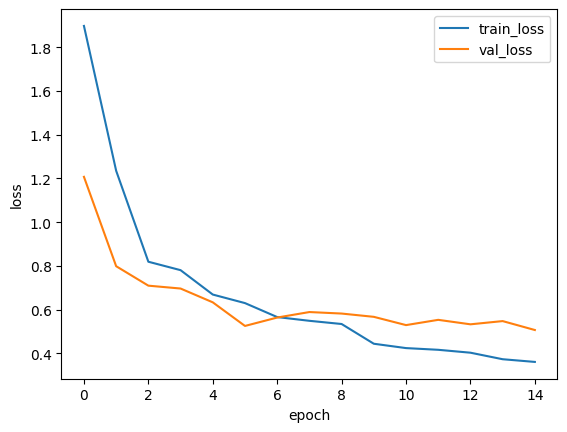

In [10]:
## Evaluate the Model
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

train_history = pd.DataFrame(transfer_history.history)
train_history['epoch'] = transfer_history.epoch
#Plot train loss
sns.lineplot(x='epoch', y ='loss', data =train_history, label='train_loss')
#Plot validation loss
sns.lineplot(x='epoch', y ='val_loss', data =train_history, label='val_loss')
#Add legends
plt.legend()

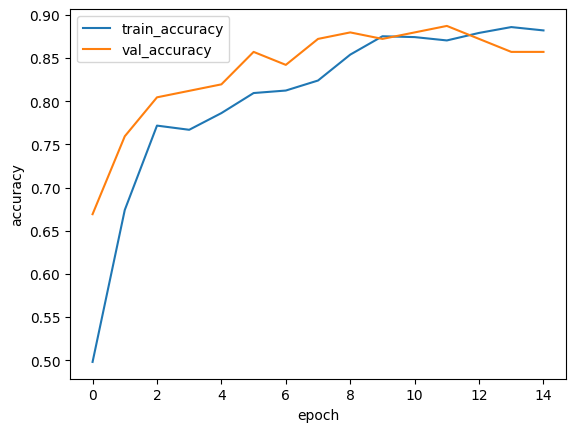

In [11]:
sns.lineplot(x='epoch', y ='accuracy', data =train_history, label='train_accuracy')
#Plot validation loss
sns.lineplot(x='epoch', y ='val_accuracy', data =train_history, label='val_accuracy')
#Add legends
plt.legend()

In [12]:
transfer_loss, transfer_accuracy = model_transfer.evaluate(test_ds_224)
print(f"Transfer Learning CNN - Test accuracy : {transfer_accuracy:.2%}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.8828 - loss: 0.5245
Transfer Learning CNN - Test accuracy : 88.28%


## The transfer learning model is achieving 88.28% accuracy.  That is an excellent result!